# Chapter 12: Generative Adversarial Networks

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Understand **GANs (Generative Adversarial Networks)** and train a small **DCGAN (Deep Convolutional Generative Adversarial Network)** on MNIST-style digits.

---

## What you will learn

1. The **generator / discriminator** adversarial game
2. **DCGAN (Deep Convolutional GAN)** architecture conventions (Conv2D (2-D convolution) generator, strided conv discriminator)
3. Train a tiny DCGAN on **8×8 digit images** for **8 epochs** (teaching demo, not production quality)
4. Display **synthetic generated images** and interpret training dynamics


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and random noise vectors |
| **Matplotlib (Mathematical Plotting Library)** | Display generated digit grids |
| **TensorFlow / Keras** | Build and train generator + discriminator |
| **scikit-learn (Scientific Kit for Learning)** | Load 8×8 digit dataset |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide TensorFlow/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import os to suppress verbose TensorFlow (deep learning framework) log messages
import os

# Set TensorFlow log level to errors only
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Matplotlib (Mathematical Plotting Library) for creating charts and image grids
import matplotlib.pyplot as plt

# Import MNIST-style 8×8 digit dataset from scikit-learn
from sklearn.datasets import load_digits

# Import TensorFlow (deep learning framework) and Keras (high-level neural network API)
import tensorflow as tf

# Import Keras layers for DCGAN (Deep Convolutional Generative Adversarial Network) building blocks
from tensorflow.keras import layers, models, optimizers

# Confirm setup completed without errors
print("Libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")


Libraries loaded successfully.
TensorFlow version: 2.21.0


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Arrays and noise sampling | Latent vectors z fed to generator |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Image grids | Visualize generated digits each epoch |
| **TensorFlow / Keras** | Deep learning | Generator and discriminator neural networks |
| **sklearn.datasets.load_digits** | 8×8 grayscale digits | Fast MNIST substitute for classroom GAN demo |


---

## Algorithms Used in This Notebook

### 1. GAN (Generative Adversarial Network)
- **Type:** Two-player minimax game
- **Generator G:** Maps random noise **z** → fake image **G(z)**
- **Discriminator D:** Classifies input as **real** or **fake**
- **Training:** G tries to fool D; D tries to detect fakes — both improve iteratively

### 2. DCGAN (Deep Convolutional GAN)
- **Generator:** Transposed convolutions (Conv2DTranspose) upsample noise to image size
- **Discriminator:** Strided Conv2D (2-D convolution) layers downsample image to real/fake logit
- **Book conventions:** BatchNorm (Batch Normalization), ReLU (Rectified Linear Unit) in G, LeakyReLU in D

### Demo note (important for beginners)

We train only **8 epochs** on **8×8 images** with a **very small network**. Output will be **blurry and imperfect** — that is expected. Production GANs need larger models, more data, and careful tuning.


---

## 1. GAN Concept — Generator vs Discriminator

```
Random noise z  ──→  Generator G  ──→  Fake image G(z)
                                              ↓
Real image x  ─────────────────────→  Discriminator D  ──→  Real or Fake?
```

| Role | Objective |
|------|-----------|
| **Discriminator** | Maximize ability to label real vs fake correctly |
| **Generator** | Minimize D's ability to detect fakes (make G(z) look real) |

**Loss intuition:** Binary cross-entropy — D penalized for wrong real/fake calls; G penalized when D correctly flags fakes.


---

## 2. Data Preparation — 8×8 Digits

We reshape digits to **(samples, 8, 8, 1)** and scale pixels to **[-1, 1]** — standard for GANs with tanh (hyperbolic tangent) output.


In [2]:
# Load 8×8 digit images
digits = load_digits()

# Reshape to (N, 8, 8, 1) for Conv2D (2-D convolution) layers
X = digits.data.reshape(-1, 8, 8, 1).astype(np.float32)

# Scale from [0, 16] to [-1, 1] for GAN training stability
X = (X / 8.0) - 1.0

# Use teaching subset for faster epochs (500 images)
X_train = X[:500]

# Image dimensions for network design
IMG_H, IMG_W, IMG_C = 8, 8, 1

print(f"Training images: {X_train.shape[0]}, shape: {X_train.shape[1:]}")


Training images: 500, shape: (8, 8, 1)


---

## 3. Build Small DCGAN (Deep Convolutional GAN)

Tiny architecture for 8×8 images:

- **Latent dim:** 32
- **Generator:** Dense → reshape 4×4×32 → upsample to 8×8×1
- **Discriminator:** Conv2D → flatten → sigmoid real/fake probability


In [3]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Latent noise vector dimension
LATENT_DIM = 32

# --- Generator ---
def build_generator():
    z = layers.Input(shape=(LATENT_DIM,))

    # Project noise to small spatial feature map
    x = layers.Dense(4 * 4 * 32)(z)

    x = layers.Reshape((4, 4, 32))(x)

    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    # Upsample 4×4 → 8×8 with transposed convolution
    x = layers.Conv2DTranspose(16, kernel_size=4, strides=2, padding="same", activation="relu")(x)

    # Output layer: 8×8 grayscale, tanh matches [-1,1] pixel range
    out = layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh")(x)

    return models.Model(z, out, name="generator")

# --- Discriminator ---
def build_discriminator():
    img = layers.Input(shape=(IMG_H, IMG_W, IMG_C))

    x = layers.Conv2D(16, kernel_size=3, strides=2, padding="same")(img)

    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)

    x = layers.Dense(64)(x)

    x = layers.LeakyReLU(0.2)(x)

    # Sigmoid outputs probability image is real
    out = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(img, out, name="discriminator")

# Instantiate models
generator = build_generator()

discriminator = build_discriminator()

# Discriminator trained on real/fake classification
discriminator.compile(
    optimizer=optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    loss="binary_crossentropy",
)

# Combined GAN: freeze D weights while training G
discriminator.trainable = False

z_input = layers.Input(shape=(LATENT_DIM,))

fake_img = generator(z_input)

pred = discriminator(fake_img)

gan = models.Model(z_input, pred, name="dcgan")

gan.compile(
    optimizer=optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    loss="binary_crossentropy",
)

discriminator.trainable = True

print(generator.summary())
print(discriminator.summary())


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 16)       │         8,208 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 1)        │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,377 (99.13 KB)

 Trainable params: 25,313 (98.88 KB)

 Non-trainable params: 64 (256.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,673 (65.13 KB)

 Trainable params: 16,673 (65.13 KB)

 Non-trainable params: 0 (0.00 B)

None


---

## 4. Train DCGAN — 8 Epochs Demo

Each epoch:
1. Train **D** on real images (label 1) and fake images (label 0)
2. Train **G** via combined model — goal: D outputs 1 (real) for fakes


Epoch 1/8 — D loss: 0.6501, G loss: 0.6347


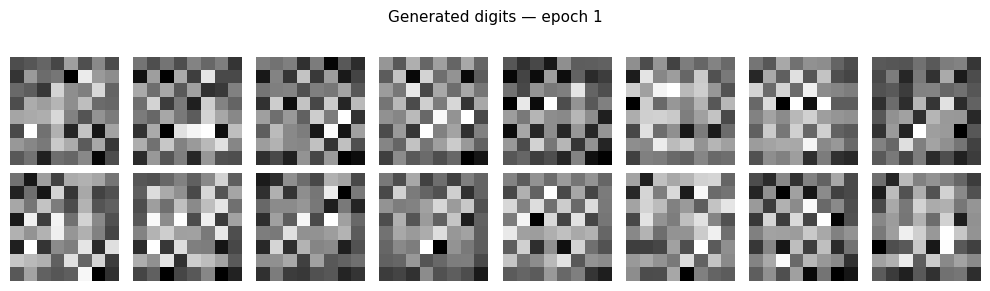

Epoch 2/8 — D loss: 0.6094, G loss: 0.5229


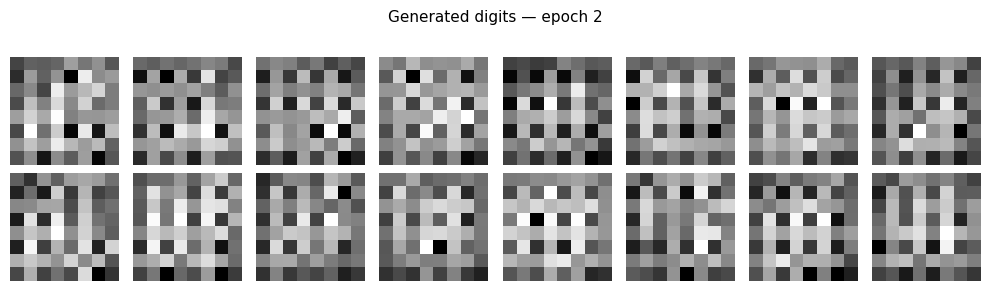

Epoch 3/8 — D loss: 0.6024, G loss: 0.4405


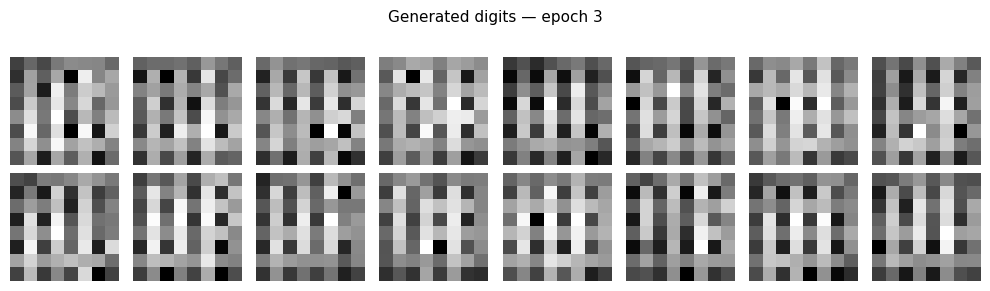

Epoch 4/8 — D loss: 0.6028, G loss: 0.3961


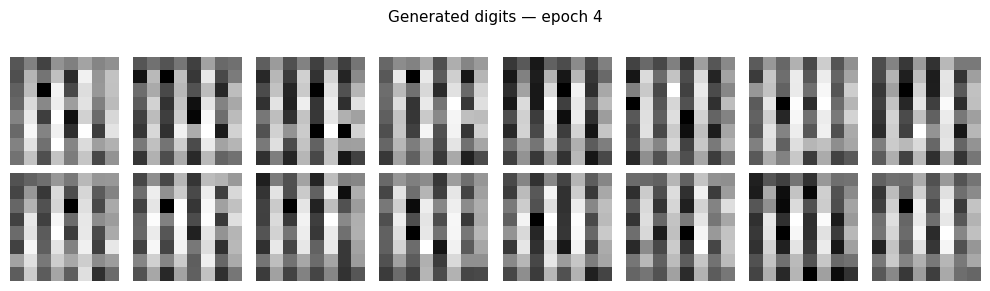

Epoch 5/8 — D loss: 0.6018, G loss: 0.3716


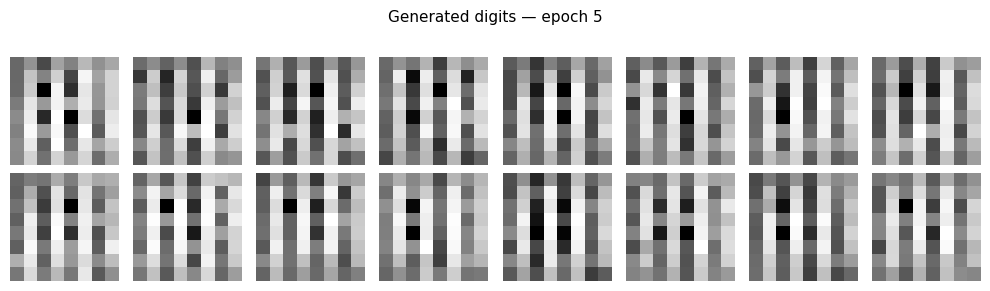

Epoch 6/8 — D loss: 0.5968, G loss: 0.3586


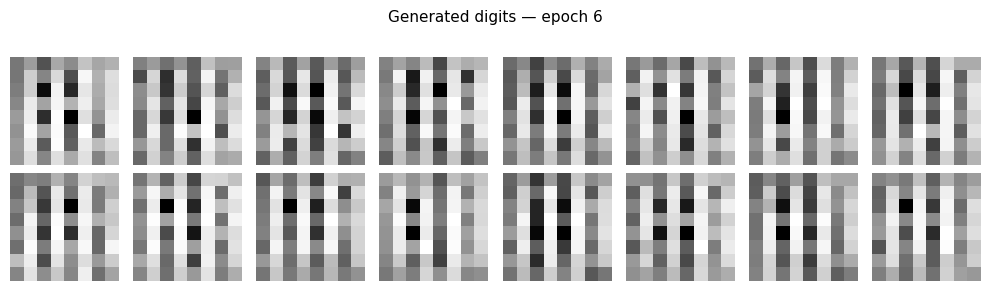

Epoch 7/8 — D loss: 0.5896, G loss: 0.3524


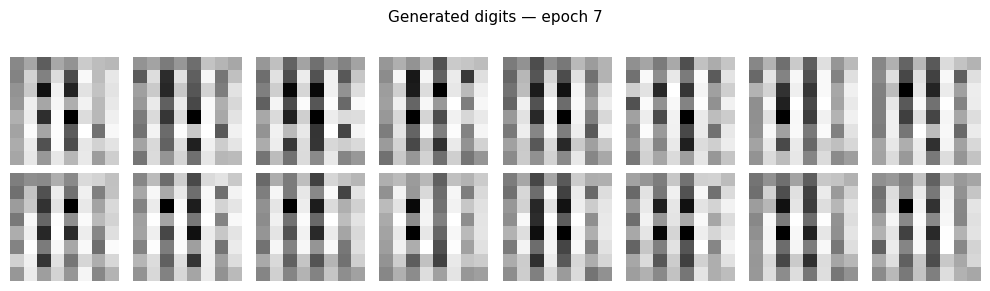

Epoch 8/8 — D loss: 0.5824, G loss: 0.3511


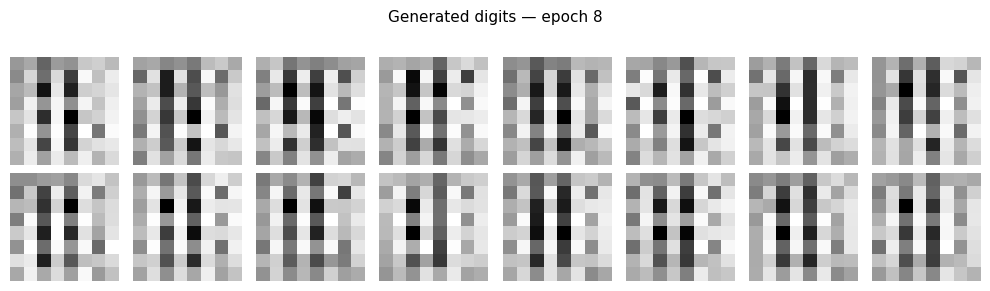

In [4]:
# Training hyperparameters (small demo)
EPOCHS = 8

BATCH_SIZE = 32

# Fixed noise vectors for consistent progress visualization
fixed_noise = np.random.normal(size=(16, LATENT_DIM)).astype(np.float32)

# Helper: plot generated images from fixed noise
def show_generated(epoch, gen_model, noise):
    imgs = gen_model.predict(noise, verbose=0)

    fig, axes = plt.subplots(2, 8, figsize=(10, 3))

    for i, ax in enumerate(axes.flat):

        ax.imshow((imgs[i, :, :, 0] + 1) / 2, cmap="gray_r")

        ax.axis("off")

    plt.suptitle(f"Generated digits — epoch {epoch}", fontsize=11)

    plt.tight_layout()

    plt.show()

# Labels for real (1) and fake (0) batches
real_label = np.ones((BATCH_SIZE, 1), dtype=np.float32)

fake_label = np.zeros((BATCH_SIZE, 1), dtype=np.float32)

# Training loop
n_batches = max(1, X_train.shape[0] // BATCH_SIZE)

for epoch in range(1, EPOCHS + 1):

    d_loss_total = 0.0

    g_loss_total = 0.0

    for _ in range(n_batches):

        # Sample real minibatch
        idx = np.random.randint(0, X_train.shape[0], size=BATCH_SIZE)

        real_imgs = X_train[idx]

        # Sample noise and generate fake images
        z = np.random.normal(size=(BATCH_SIZE, LATENT_DIM)).astype(np.float32)

        fake_imgs = generator.predict(z, verbose=0)

        # --- Train discriminator ---
        d_loss_real = discriminator.train_on_batch(real_imgs, real_label)

        d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_label)

        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        # --- Train generator (via combined GAN) ---
        z2 = np.random.normal(size=(BATCH_SIZE, LATENT_DIM)).astype(np.float32)

        g_loss = gan.train_on_batch(z2, real_label)

        d_loss_total += float(d_loss)

        g_loss_total += float(g_loss)

    print(f"Epoch {epoch}/{EPOCHS} — D loss: {d_loss_total/n_batches:.4f}, G loss: {g_loss_total/n_batches:.4f}")

    show_generated(epoch, generator, fixed_noise)


---

## 5. Glossary — All Chapter 12 Terms

| Term | One-line definition |
|------|---------------------|
| **GAN (Generative Adversarial Network)** | Generator and discriminator trained in adversarial competition |
| **Generator** | Network that creates synthetic data from random noise |
| **Discriminator** | Network that classifies real vs generated samples |
| **DCGAN (Deep Convolutional GAN)** | GAN using convolutional layers for image data |
| **Latent vector z** | Random noise input to the generator |
| **Conv2DTranspose** | Upsampling convolution — expands spatial size |
| **Binary cross-entropy** | Loss for real/fake classification |
| **Minimax game** | G minimizes while D maximizes the same objective |
| **Mode collapse** | Generator produces limited variety of outputs |
| **Batch Normalization** | Normalize layer activations for stable training |


---

## 6. Chapter 12 Summary

```
Generative Adversarial Networks (Chapter 12) — DCGAN on 8×8 digits
├── GAN = Generator (fake images) vs Discriminator (real/fake judge)
├── DCGAN uses Conv2D / Conv2DTranspose for spatial structure
├── Train D on real + fake, then train G to fool D
├── 8-epoch demo on 500 digit subset (blurry output expected)
└── Visualize generated digits each epoch with fixed noise

GANs learn to sample from data distribution without explicit density modeling
```

### What's next?

**Chapter 13** applies **time series clustering** to ECG (electrocardiogram) data — **k-Shape**, **k-Means**, and **HDBSCAN**.

---

### Practice questions

1. Why must the generator and discriminator be trained alternately?
2. Why scale pixel values to [-1, 1] when using tanh in the generator output?
3. What is **mode collapse** and how might you detect it visually?
4. How does a DCGAN differ from the fully-connected GAN in the original 2014 paper?
5. Why are 8 epochs insufficient for production-quality MNIST generation?
6. What role does the latent dimension play in output diversity?
